# Data transcript analysis

The show_consented toggle can ve check to limit the results to just those who have consented.

analysis methods include,

- Conversations per question
- Conversations per user

## Setup Google API

In [1]:
# @title Load Git Repository
!git clone https://github.com/PeaceAndLongLife/Analysis-Colab.git
%cd Analysis-Colab

import sys
from pathlib import Path
sys.path.append(str(Path("src").resolve()))
%cd notebooks

Cloning into 'Analysis-Colab'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 151 (delta 84), reused 94 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (151/151), 53.06 KiB | 1.13 MiB/s, done.
Resolving deltas: 100% (84/84), done.
/content/Analysis-Colab
/content/Analysis-Colab/notebooks


In [3]:
# @title Mount google drive and read in the SERVICE_ACCOUNT_FILE  {"form-width":"20%"}

# @markdown ---
# @markdown
# @markdown The `SERVICE_ACCOUNT_FILE` path is stored as a secret in google colab. If you do not have this sotred on your colab, contact the Admin: Travis Kregear at tkregear@pdx.edu

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# load SERVICE_ACCOUNT_FILE
from google.colab import userdata

# !pip install PyDrive

import sys
# 2. Tell Python to look in your custom folder
sys.path.append('src')

# SERVICE_ACCOUNT_FILE = userdata.get('SERVICE_ACCOUNT_FILE')
SERVICE_ACCOUNT_FILE = '/content/drive/Shareddrives/Travis Research Drive/Interface 3.0/Admin files/service_account.json'

# 3. Import your file!
from GoogleFunctions import GoogleDocumentManager, extract_file_id
from local_io import read_csv_from_id


Mounted at /content/drive
The 'extract_file_id' function has been defined.


## Read in data

data read in will be merged using the `user` column

- consent file
- transcript data

In [4]:

# @ title ## Input Data Links  {"form-width":"20%"}
# @markdown ---
# Consent data info
# @markdown Read in consent file {"form-width":"20%"}
consent_file_link = "https://drive.google.com/file/d/1OBOz23ByNoxk7L2-DMKa3rhR_U9G56b-/view?usp=drive_link" # @param {"type":"string"}
consent_file_link_id = extract_file_id(consent_file_link)
show_consent = False # @param {"type":"boolean"}

# Transcript Data info
# @markdown Read in transcript file {"form-width":"20%"}
trans_file_link = "https://drive.google.com/file/d/1Q4G-RJAXd0GgkCyJpA8ajTXTk0hOyQhe/view?usp=drive_link" # @param {"type":"string"}
trans_file_link_id = extract_file_id(trans_file_link)
show_trans = False # @param {"type":"boolean"}

consent_df = read_csv_from_id(SERVICE_ACCOUNT_FILE, consent_file_link_id, show_consent)
trans_df = read_csv_from_id(SERVICE_ACCOUNT_FILE, trans_file_link_id, show_trans)

display(trans_df)

Google Drive API service built successfully.
Reading in csv file. id=1OBOz23ByNoxk7L2-DMKa3rhR_U9G56b-
Google Drive API service built successfully.
Reading in csv file. id=1Q4G-RJAXd0GgkCyJpA8ajTXTk0hOyQhe


,user,created_at,question,thread,model,personalityPrompt,prompt,all_messages
0,194,2025-10-04 03:02:32.694244+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0a9f2bcde0f87e180068e42671424c81988e2dff8...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""do i answer these qu..."
1,126,2025-10-07 05:02:11.115686+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0c304934d3ea40cf0068e5b5b13d18819989044af...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""how do i submit all ..."
2,156,2025-09-30 03:41:36.520675+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0c7bb5598f9254020068e5e0a066b48198acc0a0a...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""do these answers hav..."
3,115,2025-09-30 04:31:06.149084+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0505993b7950b07d0068de2258a398819b996942a...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""what is the THEORY f..."
4,149,2025-09-30 20:37:33.619255+00:00,"PH214 (online) - Assignment 1, Question: 4 - F...",resp_0026af49bf0edc580068e296104eac819a8715182...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""The most minimum unc..."
...,...,...,...,...,...,...,...,...
1237,138,2025-11-30 21:45:02.513771+00:00,"PH214 (online) - Assignment 8, Question: 0 - H...",resp_04d9a749055e221500692cf9228354819885abd84...,gpt-5-mini-2025-08-07-Response,Default Prompt,"You are a clear, engaging, and encouraging phy...","[{""data"": false, ""text"": ""what is the learning..."
1238,159,2025-10-23 23:41:12.735939+00:00,"PH214 (online) - Assignment 4, Question: 0 - H...",resp_063b365b539862dc00693a2baa8844819a9aa758f...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""do I mark where it l..."
1239,159,2025-10-23 23:41:12.754439+00:00,"PH214 (online) - Assignment 4, Question: 2 - U...",resp_05bfdd38a9fb2066006936448c72688196a488633...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""if \u0394y= 38 cm, \..."
1240,159,2025-10-23 23:41:12.772390+00:00,"PH214 (online) - Assignment 4, Question: 4 - W...",resp_0a31162129e6caa800693a29a07a208199b11eae4...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""how do i find that v..."


In [6]:
from data_scrub import process_messages, parse_messages, explode_json_messages
import pandas as pd
import re

###
# Merge consent into transcript
combined_df = process_messages(
    consent_df,
    trans_df,
    pattern = r"(.+) - Assignment (\d+), Question: (\d+) - (.+)",
)
# Apply the parsing function to the 'all_messages' column
combined_df['all_messages'] = combined_df['all_messages'].apply(parse_messages)

# Count message objects in 'all_messages' and add to 'interactions' column
combined_df['interactions'] = combined_df['all_messages'].apply(len)

combined_df = combined_df[combined_df['all_messages'].apply(lambda x: len(x) > 0)]

print("Combined DataFrame with split question columns and interactions:")
# display(combined_df.head())

combined_df = explode_json_messages(combined_df)
display(combined_df.head())

Consent Data Combined into DataFrame.
 Question Data parsed and updated.
Combined DataFrame with split question columns and interactions:


,user,consent,created_at,question,thread,model,personalityPrompt,prompt,Course,lab_number,question_number,question_text,interactions,data,text,sender,timestamp,instructions,rating
0,241,False,2025-10-04 02:09:28.324102+00:00,PH214 (online) - Lab 02-Q01,resp_04fefcdc648f27b10068e48b4966648199b25b182...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,PH214 (online),02,01,"Calculate your average value of $\pi$, and the...",2,False,is this question apart of the lab report,You,2025-10-07T03:39:12.032790+00:00,None,NaN
1,241,False,2025-10-04 02:09:28.324102+00:00,PH214 (online) - Lab 02-Q01,resp_04fefcdc648f27b10068e48b4966648199b25b182...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,PH214 (online),02,01,"Calculate your average value of $\pi$, and the...",2,False,Lab 2 (Data Analysis) includes a Questions sec...,Bot,2025-10-07T03:39:12.035829+00:00,You are a thoughtful and encouraging physics t...,NaN
2,141,True,2025-10-08 04:16:15.173318+00:00,PH214 (online) - Lab 02-Q01,resp_0e294df7a35f511b0068eda195df2881979c3b4e4...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,PH214 (online),02,01,"Calculate your average value of $\pi$, and the...",2,False,The average value of Pi is 3.138 with a standa...,You,2025-10-13T18:04:56.171265-07:00,None,NaN
3,141,True,2025-10-08 04:16:15.173318+00:00,PH214 (online) - Lab 02-Q01,resp_0e294df7a35f511b0068eda195df2881979c3b4e4...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,PH214 (online),02,01,"Calculate your average value of $\pi$, and the...",2,False,You measured π by measuring circumferences and...,Bot,2025-10-14T01:04:56.174440+00:00,"You are a clear, engaging, and encouraging phy...",NaN
4,141,True,2025-10-06 20:20:05.231355+00:00,PH214 (online) - Lab 01-Q02,resp_04a0c6ece937672a0068e46907b7d4819a9cb5351...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,PH214 (online),01,02,"Based on the scale presented in Figure 1.2, ho...",6,False,+ or - 1kg uncertainty,You,2025-10-07T01:11:26.248070+00:00,None,NaN


## Analysis

### Analysis Functions

In [7]:
# @title analyze_stats function
def analyze_hist(df, drop_counts_under_param,y,x):
  # Exclude users with less than drop_counts_under_param unique threads
  df_filtered = df[df[y] >= drop_counts_under_param]


  ### Plot distribution
  import matplotlib.pyplot as plt
  import seaborn as sns

  # Set the style for the plot
  sns.set_style("whitegrid")

  plt.figure(figsize=(10, 6))
  sns.histplot(df_filtered[y], bins=50, kde=True)
  plt.title(f"Distribution of {y} per {x}")
  plt.xlabel(f"{x}")
  # plt.ylabel(f"Number of {y}")
  plt.tight_layout()
  plt.show()
  display(df_filtered[y].describe())


In [8]:
# @title Bar graph function
def analyze_bar_graph(df, x_col, y_col, title="Bar Graph Distribution", x_label=None, y_label=None, tick_label_size=10):
  import matplotlib.pyplot as plt
  import seaborn as sns

  # Set the style for the plot
  sns.set_style("whitegrid")

  plt.figure(figsize=(12, 6))
  sns.barplot(x=x_col, y=y_col, data=df.sort_values(by=y_col, ascending=False))

  # Add labels and title
  if x_label is None:
    x_label = x_col.replace('_', ' ').title()
  if y_label is None:
    y_label = y_col.replace('_', ' ').title()

  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.title(title)

  # Ensure x-axis labels are always horizontal
  plt.xticks(rotation=90)

  # Adjust tick label size
  plt.tick_params(axis='x', labelsize=tick_label_size)
  plt.tick_params(axis='y', labelsize=tick_label_size)

  plt.tight_layout()
  plt.show()

In [9]:
# @title export_data_csv
def export_data_csv(df, output_df_name,folder_link):
  folder_id = extract_file_id(folder_link)
  gdm = GoogleDocumentManager(SERVICE_ACCOUNT_FILE)
  output_filename = f"{output_df_name}.csv"

  if not folder_id:
    print(f"Error: No target folder ID provided for '{output_filename}'. Please enter a valid Google Drive Folder ID.")
    return
  try:
      uploaded_file_id = gdm.upload_dataframe_to_drive(df, output_filename, folder_id, include_index=False)

      if uploaded_file_id:
          print(f"Successfully saved '{output_df_name}' DataFrame to '{output_filename}'. File ID: {uploaded_file_id}")

      else:
          print(f"Failed to upload '{output_df_name}' DataFrame to '{output_filename}'. See previous error messages.")
  except Exception as e:
      print(f"Error saving '{output_df_name}' DataFrame to '{output_filename}': {e}")
  return


  ###
  # Example implementation

  ## @markdown ---
# export_table = False # @param {"type":"boolean"}
# output_name = "conversations_by_question" # @param {"type":"string","placeholder":"Enter the name of the csv file"}
# target_folder_link = "https://drive.google.com/drive/folders/1Jz9QrU0ZmhCQn4GWh_wa9WtUPzcW2s-s?usp=drive_link" # @param {"type":"string","placeholder":"Enter YOUR_GOOGLE_DRIVE_FOLDER_ID_HERE"}

# if export_table:
#   export_data_csv(df,output_name, target_folder_link)

### Analysis Criteria

Unique user counts per question:


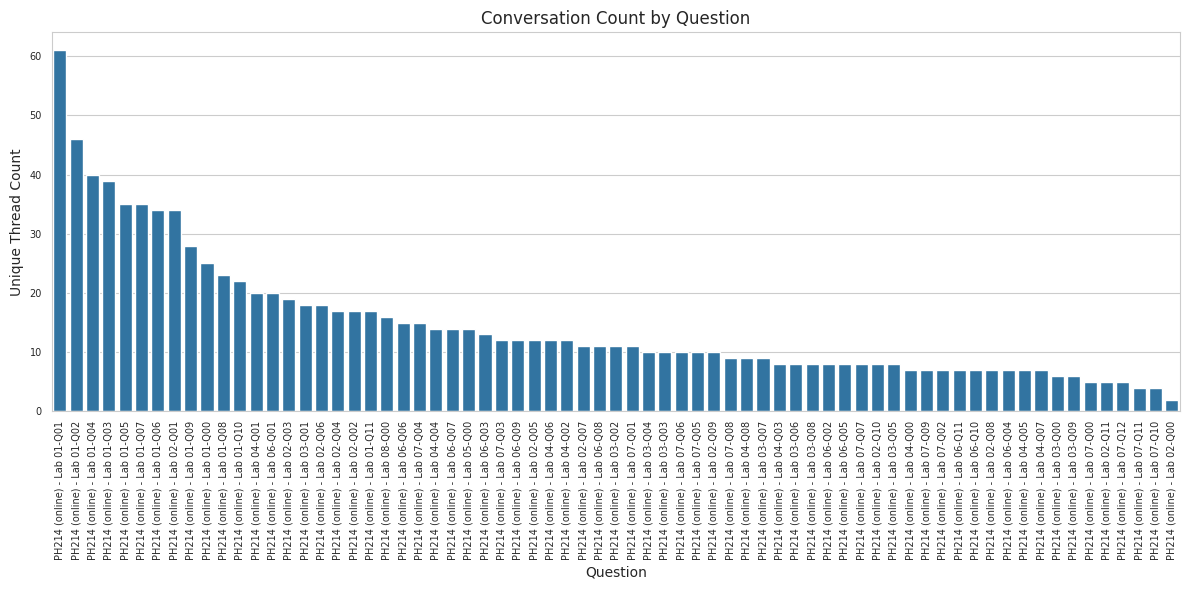

,Course,lab_number,question_number,question,unique_thread_count
1,PH214 (online),01,01,PH214 (online) - Lab 01-Q01,61
2,PH214 (online),01,02,PH214 (online) - Lab 01-Q02,46
4,PH214 (online),01,04,PH214 (online) - Lab 01-Q04,40
3,PH214 (online),01,03,PH214 (online) - Lab 01-Q03,39
5,PH214 (online),01,05,PH214 (online) - Lab 01-Q05,35
...,...,...,...,...,...
23,PH214 (online),02,11,PH214 (online) - Lab 02-Q11,5
67,PH214 (online),07,12,PH214 (online) - Lab 07-Q12,5
66,PH214 (online),07,11,PH214 (online) - Lab 07-Q11,4
65,PH214 (online),07,10,PH214 (online) - Lab 07-Q10,4


In [10]:
# @title count conversations by question {"form-width":"20%"}
show_consented = True # @param {"type":"boolean"}
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}
# @markdown the x axis represents the question sorted by lab, then number.

if show_consented:
  current_df = combined_df[combined_df['consent'] == True]
else:
  current_df = combined_df

thread_counts_df = current_df.groupby(['Course', 'lab_number', 'question_number', 'question', ])['thread'].nunique().reset_index().sort_values(by=['lab_number', 'question_number'])
thread_counts_df.rename(columns={'thread': 'unique_thread_count'}, inplace=True)
# thread_counts_df = thread_counts_df.sort_values(by=['question'])
print("Unique user counts per question:")
analyze_bar_graph(thread_counts_df, 'question', 'unique_thread_count', 'Conversation Count by Question', tick_label_size=7)
display(thread_counts_df.sort_values(by=['unique_thread_count'], ascending=False))


Unique user counts per lab:


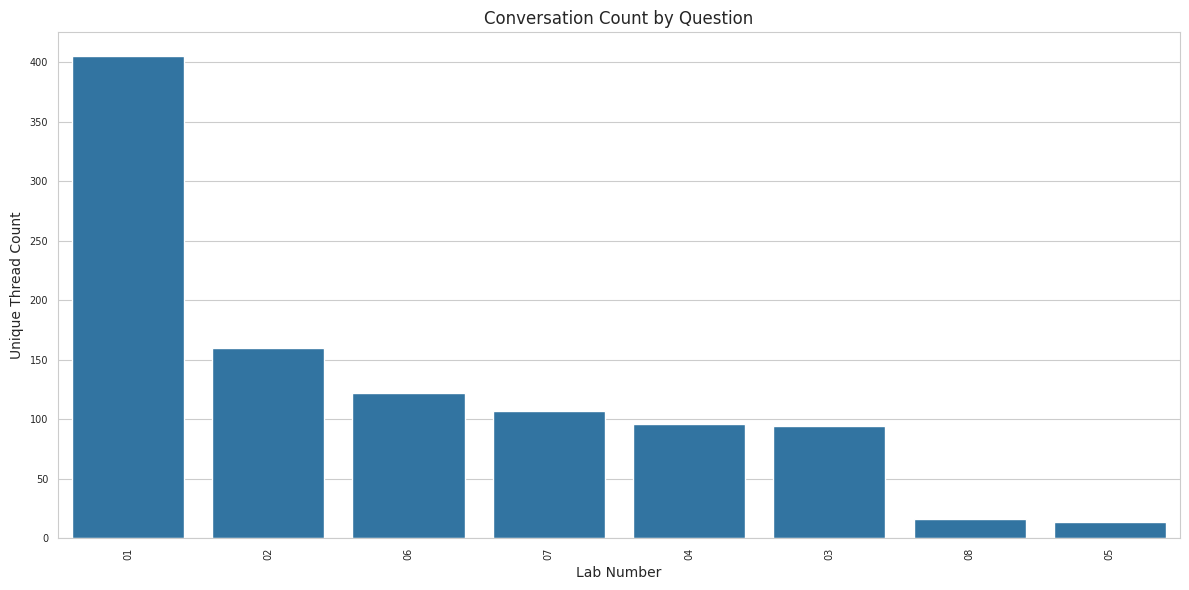

,Course,lab_number,unique_thread_count
0,PH214 (online),01,405
1,PH214 (online),02,160
5,PH214 (online),06,122
6,PH214 (online),07,107
3,PH214 (online),04,96
2,PH214 (online),03,94
7,PH214 (online),08,16
4,PH214 (online),05,14


In [11]:
# @title count conversations by lab_number {"form-width":"20%"}
show_consented = True # @param {"type":"boolean"}
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}
# @markdown the x axis represents the lab number.

if show_consented:
  current_df = combined_df[combined_df['consent'] == True]
else:
  current_df = combined_df

thread_counts_df = current_df.groupby(['Course', 'lab_number'])['thread'].nunique().reset_index().sort_values(by=['lab_number'])
thread_counts_df.rename(columns={'thread': 'unique_thread_count'}, inplace=True)
# thread_counts_df = thread_counts_df.sort_values(by=['question'])
print("Unique user counts per lab:")
analyze_bar_graph(thread_counts_df, 'lab_number', 'unique_thread_count', 'Conversation Count by Question', tick_label_size=7)
display(thread_counts_df.sort_values(by=['unique_thread_count'], ascending=False))


Unique thread counts per user and lab_number:


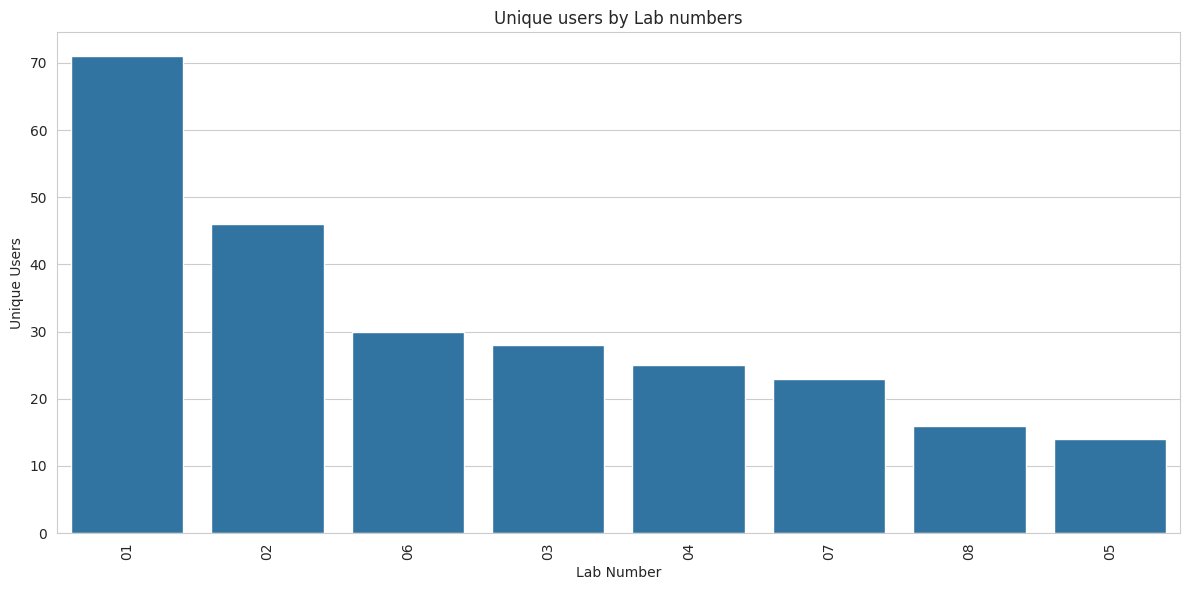

,lab_number,unique_users
0,01,71
1,02,46
5,06,30
2,03,28
3,04,25
6,07,23
7,08,16
4,05,14


In [12]:
# @title count users per lab {"form-width":"20%"}
show_consented = True # @param {"type":"boolean"}

if show_consented:
  current_df = combined_df[combined_df['consent'] == True]
else:
  current_df = combined_df

lab_counts_df = current_df.groupby(['Course', 'lab_number'])['user'].nunique().reset_index()
lab_counts_df.rename(columns={'user': 'unique_users'}, inplace=True)
lab_counts_df = lab_counts_df[['lab_number','unique_users']].sort_values(by=['unique_users'], ascending=False)
print("Unique thread counts per user and lab_number:")
analyze_bar_graph(lab_counts_df,'lab_number', 'unique_users', "Unique users by Lab numbers")
display(lab_counts_df)


Unique thread per user


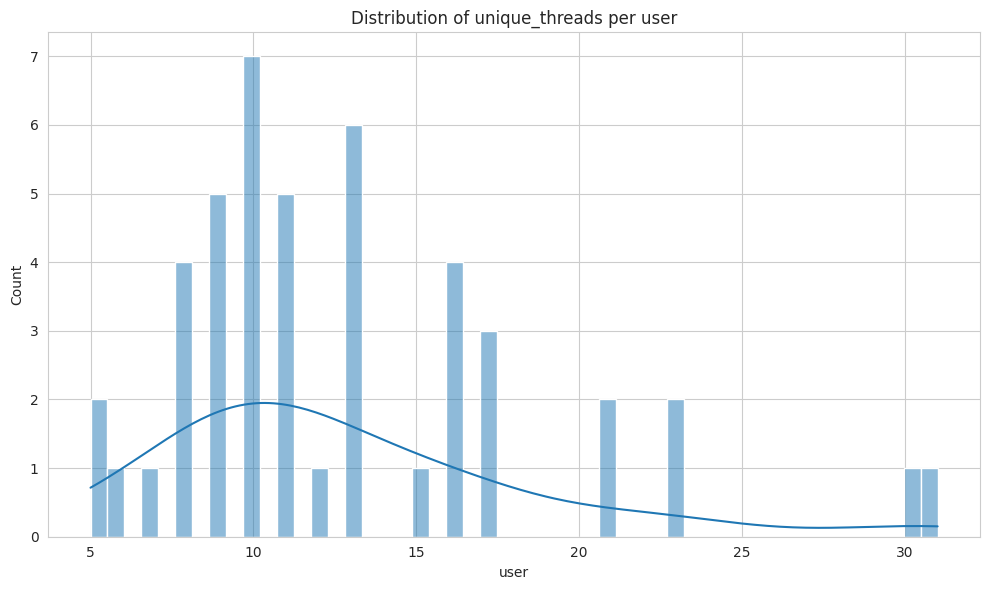

,unique_threads
count,46.000000
mean,12.913043
std,5.784370
min,5.000000
25%,9.000000
50%,11.000000
75%,16.000000
max,31.000000


,user,unique_threads
72,252,31
29,139,30
1,79,23
71,245,23
59,225,21
...,...,...
50,197,1
60,227,1
55,217,1
65,235,1


----


greater or equal to 45 conversations. count: 0


,user,unique_threads


----


Between 22 and 45 conversations. count: 4


...

,user,unique_threads
59,225,21
4,85,21
16,106,17
20,121,17
54,215,17
19,111,16
56,219,16
76,263,16
64,234,16
68,239,15


----


Between 5 and 13 conversations. count: 26


,user,unique_threads
30,141,12
35,151,11
49,196,11
13,101,11
9,92,11
18,109,11
5,88,10
38,159,10
66,236,10
73,256,10


----


Less than 5. count: 32


,user,unique_threads
40,167,4
70,244,4
14,103,4
77,267,3
2,83,3
0,78,3
58,223,3
7,90,3
37,156,3
53,209,3


In [13]:
# @title count conversations by user {"run":"auto","form-width":"20%"}
show_consented = True # @param {"type":"boolean"}

drop_counts_under = 5 # @param {"type":"slider","min":0,"max":100,"step":1}
# @markdown "4 groups: x<5, 5<x<13, 13<x<22, 22<x<45, 45<x"
filter_by_lab_number = "04" # @param ["01","02","03","04","05","06","07","08","False"] {"allow-input":true}

# Call the function with the relevant DataFrame and parameter
if show_consented:
  current_df = combined_df[combined_df['consent'] == True]
else:
  current_df = combined_df
if filter_by_lab_number != "False":
  current_df = current_df[current_df['lab_number'] < filter_by_lab_number]

lab_counts_df = current_df.groupby(['Course','user'])['thread'].nunique().reset_index()
lab_counts_df.rename(columns={'thread': 'unique_threads'}, inplace=True)

lab_counts_df = lab_counts_df.sort_values(by='unique_threads', ascending=False)

print("Unique thread per user")
import ipywidgets as widgets
from IPython.display import display

# analyze_hist(lab_counts_df, drop_counts_under,'unique_threads','user'
analyze_hist(lab_counts_df, drop_counts_under,'unique_threads','user')
# analyze_bar_graph(lab_counts_df,'user', 'unique_threads', "Unique threads per user")
display(lab_counts_df[['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False))

print("----\n\n")
# x>=45
group5 = lab_counts_df[lab_counts_df['unique_threads']>=45][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"greater or equal to 45 conversations. count: {len(group5)}")
display(group5)

print("----\n\n")
# 22<=x<45
group4 = lab_counts_df[(lab_counts_df['unique_threads']<45) & (lab_counts_df['unique_threads']>=22)][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Between 22 and 45 conversations. count: {len(group4)}")
display(group4)


print("----\n\n")
# 13<=x<22
group3 = lab_counts_df[(lab_counts_df['unique_threads']<22) & (lab_counts_df['unique_threads']>=13)][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Between 13 and 22 conversations. count: {len(group3)}")
display(group3)

print("----\n\n")
# 5<=x<13
group2 = lab_counts_df[(lab_counts_df['unique_threads']<13) & (lab_counts_df['unique_threads']>=5)][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Between 5 and 13 conversations. count: {len(group2)}")
display(group2)

print("----\n\n")
# 5>x
group1 = lab_counts_df[lab_counts_df['unique_threads']<5][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Less than 5. count: {len(group1)}")
display(group1)


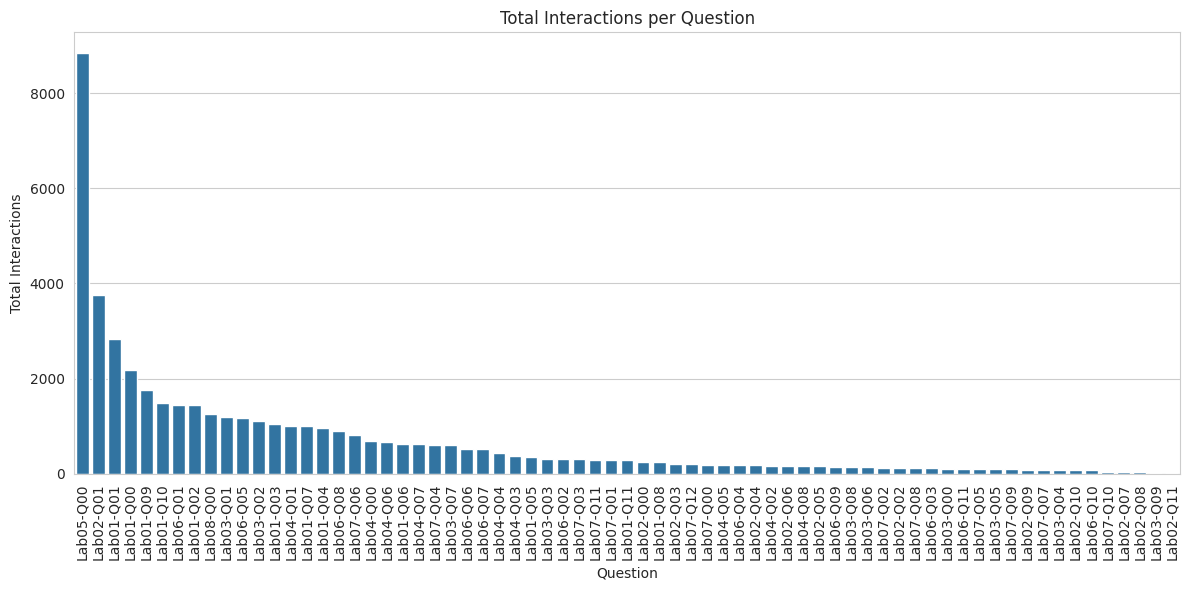

,full_question,interactions
43,Lab05-Q00,8836
13,Lab02-Q01,3748
1,Lab01-Q01,2836
0,Lab01-Q00,2184
9,Lab01-Q09,1752
...,...,...
65,Lab07-Q10,48
19,Lab02-Q07,44
20,Lab02-Q08,40
33,Lab03-Q09,24


In [14]:
# @title Total Interactions by Question Plot {"form-width":"20%"}
show_consented = True # @param {"type":"boolean"}

if show_consented:
  current_df = combined_df[combined_df['consent'] == True]
else:
  current_df = combined_df

interactions_by_question = current_df.groupby(['Course', 'lab_number', 'question_number', 'question_text'])['interactions'].sum().reset_index()

# Create a combined question identifier for the x-axis labels if needed, or use existing columns
interactions_by_question['full_question'] = 'Lab' + interactions_by_question['lab_number'] + '-Q' + interactions_by_question['question_number']
analyze_bar_graph(
    df=interactions_by_question,
    x_col='full_question',
    y_col='interactions',
    title='Total Interactions per Question',
    x_label='Question',
    y_label='Total Interactions'
)
interactions_by_question = interactions_by_question.sort_values(by='interactions', ascending=False)
display(interactions_by_question[['full_question','interactions']])


# @markdown ---
export_table = False # @param {"type":"boolean"}
output_name = "conversations_by_question" # @param {"type":"string","placeholder":"Enter the name of the csv file"}
target_folder_link = "https://drive.google.com/drive/folders/1Jz9QrU0ZmhCQn4GWh_wa9WtUPzcW2s-s?usp=drive_link" # @param {"type":"string","placeholder":"Enter YOUR_GOOGLE_DRIVE_FOLDER_ID_HERE"}

if export_table:
  export_data_csv(interactions_by_question[['full_question','interactions']],output_name, target_folder_link)

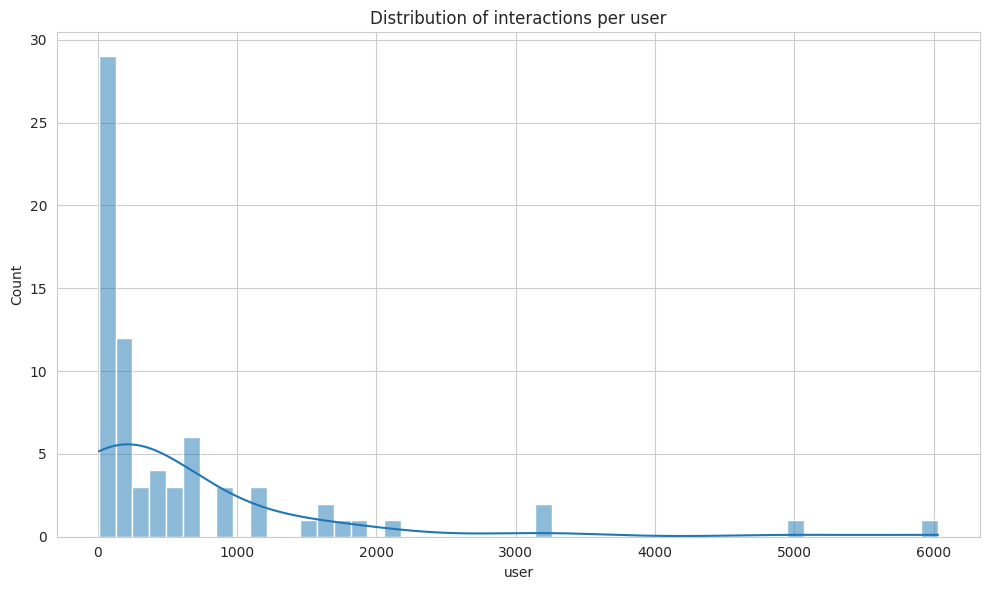

,interactions
count,73.000000
mean,634.630137
std,1068.117601
min,8.000000
25%,76.000000
50%,224.000000
75%,680.000000
max,6032.000000


,user,interactions
39,159,6032
54,203,4980
77,256,3232
72,240,3168
32,144,2060
...,...,...
33,146,4
58,217,4
55,204,4
52,197,4


----


greater or equal to 229 conversations. count: 35


,user,interactions
39,159,6032
54,203,4980
77,256,3232
72,240,3168
32,144,2060
40,160,1840
70,237,1704
35,149,1648
62,225,1584
17,106,1472


----


Between 104 and 229 conversations. count: 14


...

,user,interactions
2,83,96
66,233,96
74,244,84
25,130,76
81,267,76
5,88,76
29,138,68
9,92,68
15,103,56
23,124,52


----


Between 7 and 50 conversations. count: 14


,user,interactions
42,169,36
7,90,28
65,231,20
18,107,16
78,260,16
22,122,16
3,84,12
28,136,12
61,223,12
6,89,8


----


Less than 7. count: 9


,user,interactions
14,102,4
48,185,4
47,183,4
37,155,4
33,146,4
58,217,4
55,204,4
52,197,4
68,235,4


In [15]:
# @title Total Interactions by User Plot {"run":"auto","form-width":"20%"}
show_consented = True # @param {"type":"boolean"}
drop_counts_under = 7 # @param {"type":"slider","min":0,"max":100,"step":1}

if show_consented:
  current_df = combined_df[combined_df['consent'] == True]
else:
  current_df = combined_df

interactions_by_user = current_df.groupby(['user'])['interactions'].sum().reset_index()

# Create a combined question identifier for the x-axis labels if needed, or use existing columns
# interactions_by_question['full_question'] = 'Lab' + interactions_by_question['lab_number'] + '-Q' + interactions_by_question['question_number']
# analyze_bar_graph(
#     df=interactions_by_user,
#     x_col='user',
#     y_col='interactions',
#     title='Total Interactions per User',
#     x_label='User',
#     y_label='Total Interactions'
# )
analyze_hist(interactions_by_user, drop_counts_under,'interactions','user')
interactions_by_user = interactions_by_user.sort_values(by='interactions', ascending=False)
display(interactions_by_user[['user','interactions']])
#############################
print("----\n\n")
# x>=45
group5 = interactions_by_user[interactions_by_user['interactions']>=229][['user','interactions']].sort_values(by=['interactions'], ascending=False)
print(f"greater or equal to 229 conversations. count: {len(group5)}")
display(group5)

print("----\n\n")
# 22<=x<45
group4 = interactions_by_user[(interactions_by_user['interactions']<229) & (interactions_by_user['interactions']>=104)][['user','interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Between 104 and 229 conversations. count: {len(group4)}")
display(group4)


print("----\n\n")
# 13<=x<22
group3 = interactions_by_user[(interactions_by_user['interactions']<104) & (interactions_by_user['interactions']>=50)][['user','interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Between 50 and 104 conversations. count: {len(group3)}")
display(group3)

print("----\n\n")
# 5<=x<13
group2 = interactions_by_user[(interactions_by_user['interactions']<50) & (interactions_by_user['interactions']>=7)][['user','interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Between 7 and 50 conversations. count: {len(group2)}")
display(group2)

print("----\n\n")
# 5>x
group1 = interactions_by_user[interactions_by_user['interactions']<7][['user','interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Less than 7. count: {len(group1)}")
display(group1)

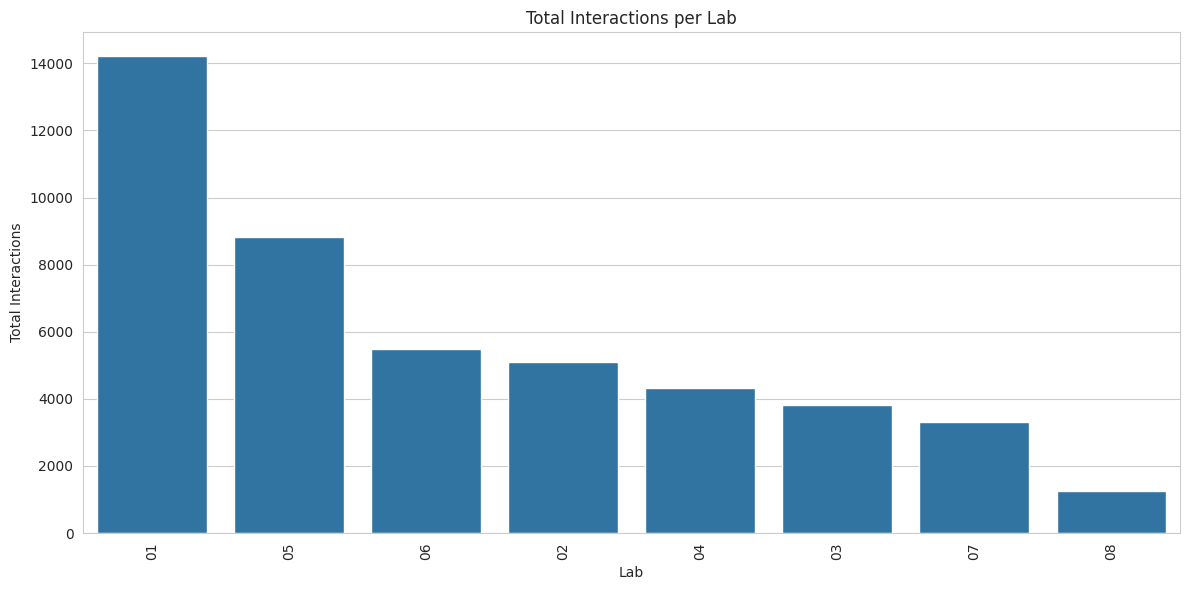

,lab_number,interactions_by_lab
0,01,14212
4,05,8836
5,06,5492
1,02,5108
3,04,4320
2,03,3820
6,07,3320
7,08,1256


In [16]:
# @title Total Interactions by Question Plot {"run":"auto","form-width":"20%"}
show_consented = True # @param {"type":"boolean"}
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}

if show_consented:
  current_df = combined_df[combined_df['consent'] == True]
else:
  current_df = combined_df

interactions_by_lab = current_df.groupby(['Course', 'lab_number'])['interactions'].sum().reset_index()
interactions_by_lab.rename(columns={'interactions': 'interactions_by_lab'}, inplace=True)
# Create a combined question identifier for the x-axis labels if needed, or use existing columns
# interactions_by_question['full_question'] = 'Lab' + interactions_by_question['lab_number'] + '-Q' + interactions_by_question['question_number']
analyze_bar_graph(
    df=interactions_by_lab,
    x_col='lab_number',
    y_col='interactions_by_lab',
    title='Total Interactions per Lab',
    x_label='Lab',
    y_label='Total Interactions'
)
interactions_by_lab = interactions_by_lab.sort_values(by='interactions_by_lab', ascending=False)
display(interactions_by_lab[['lab_number','interactions_by_lab']])

In [17]:
# @title last lab {"run":"auto","form-width":"20%"}
current_df = combined_df
filter_by_lab_number = "04" # @param ["01","02","03","04","05","06","07","08","False"] {"allow-input":true}


last_lab_per_user = current_df.groupby('user')['lab_number'].max().reset_index()
last_lab_per_user.rename(columns={'lab_number': 'last_lab_number'}, inplace=True)
if filter_by_lab_number != "False":
  last_lab_per_user = last_lab_per_user[last_lab_per_user['last_lab_number'] == filter_by_lab_number]

print("Last (highest) lab number for each user:")
display(last_lab_per_user.sort_values(by='last_lab_number', ascending=False))

Last (highest) lab number for each user:


,user,last_lab_number
1,79,04
14,99,04
15,101,04
38,136,04
44,144,04
64,182,04
74,198,04
98,236,04
109,256,04


In [18]:
# from google.colab import sheets

# # @title Create Interactive Sheet and optionally move to a specific folder {"form-width":"20%"}
# move_to_target_folder = True # @param {type:"boolean"}
# target_folder_for_sheet_link = "https://drive.google.com/drive/folders/1KeIQKtAkXxhU6mB8uzd8Nw3_Ji7Oroyx?usp=drive_link" # @param {type:"string"}
# sheet_name = "transcript_analysis_Jan14" # @param {"type":"string"}

# # Create the interactive sheet
# sheet_object = sheets.InteractiveSheet(title=sheet_name, include_column_headers=True, df=combined_df)

# # Get the ID of the newly created sheet
# sheet_id = sheet_object.id
# print(f"Interactive Sheet created with ID: {sheet_id}")
# print(f"Interactive Sheet URL: {sheet_object.url}")

# if move_to_target_folder:
#   if 'GDM' not in globals():
#     GDM = GoogleDocumentManager(SERVICE_ACCOUNT_FILE)

#   target_folder_id = extract_file_id(target_folder_for_sheet_link)
#   if target_folder_id:
#     try:
#       # Get current parent(s) to remove from
#       current_parents = GDM.get_file_parent_info(file_id=sheet_id)['parents']
#       current_parent_ids = [p['id'] for p in current_parents]

#       # Move the file by updating its parents
#       GDM.update_file_metadata(
#           file_id=sheet_id,
#           add_parents=target_folder_id,
#           remove_parents=','.join(current_parent_ids)
#       )
#       print(f"Successfully moved Interactive Sheet (ID: {sheet_id}) to folder (ID: {target_folder_id})")
#     except Exception as e:
#       print(f"Error moving sheet to target folder: {e}")
#       print("Please ensure the target folder link is valid and you have appropriate permissions.")
#   else:
#     print(f"Invalid target folder link provided: {target_folder_for_sheet_link}")
